# Experiment 2: Relevance-Aware DRAM Caching

**Baseline**: `M3-Baseline.ipynb` running `full_EdgeRAG.yaml` on `arch/basic8.yaml`  
(gte-base-en-v1.5 encoder + flat dense retrieval + Sheared-LLaMA-2.7B decoder, INT8)

> **Scope**: We use the basic8 accelerator (LPDDR5 68 GB/s, NVMe disk 7 GB/s),
> EdgeRAG's model scale, and LFU cache policy, simplifying retrieval to flat dense search
> to isolate memory hierarchy effects. Latency results are framed as **TTFT** contributions.
> IVF indexing internals are out of scope.

## Hypotheses
1. Memory accesses dominate energy and TTFT at large retrieval scales.
2. DRAM caching reduces TTFT at the cost of higher DRAM traffic energy.
3. There exists a break-even frontier where caching transitions from costing more energy
   than the no-cache baseline to costing less, as DRAM capacity and reuse ratio grow.

## What this notebook does
- Loads the AccelForge baseline from `baseline_cache.pkl` (produced by the last cell of `M3-Baseline.ipynb`).
- Uses hardware constants from `arch/basic8.yaml`: LPDDR5 at 68 GB/s and NVMe disk at 7 GB/s.
- Generates a synthetic Zipf-distributed document-access trace per BEIR reuse ratio (Table 2).
- Runs the triple sweep `(DRAM_GB, reuse_ratio, policy)` through `cache_sim.py`.
- Converts hit/miss counts to energy, TTFT latency, and EDP, adding the non-SIM AccelForge baseline.
- Runs a full sanity-check suite before producing plots.
- Produces heatmaps, the LFU-vs-OPT gap plot, and a hit-rate bar chart.

**Results are reported as-is. No interpretation of whether they support or contradict the hypotheses is made here.**

---
### Note on parameter scale
The AccelForge baseline (`M3-Baseline.ipynb`) maps the EdgeRAG workload at
`N_DOCS = 5 000 000`, `K = 10`, `N_TOKENS = 512`. The full pipeline costs ~6 J / 691 s per query;
the `doc_scores` SIM term that the cache replaces costs ~474 mJ / 3.84 s per query.

The cache simulator is intentionally decoupled from AccelForge `N_DOCS`: it only needs a
corpus large enough that the DRAM sweep crosses the eviction frontier. We use
`N_DOCS_TRACE = 2 000 000`, `N_QUERIES = 100 000`, `K_SIM = 10`, and a DRAM sweep of
`{0.25, 0.5, 1, 2, 4} GB`. With reuse ratios from BEIR Table 2, the worst-case unique-doc
count is ~800 k, which forces evictions at 0.25 GB / 0.5 GB and saturates the cache at 1+ GB.
Override `N_DOCS_TRACE` and `N_QUERIES` in Cell 2 and re-run if you want to shift the frontier.

## Cell 1 — Imports

In [1]:
import sys, os, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.insert(0, '/home/workspace/workspace')
sys.path.insert(0, '/home/workspace/workspace/scripts')

from cache_sim import (
    synth_trace,
    simulate_no_cache,
    simulate_lfu_cost_aware,
    simulate_belady_opt,
    CacheResult,
)

%matplotlib inline
print('Imports OK')

Imports OK


## Cell 2 — Parameters

In [2]:
# ── AccelForge workload parameters (must match M3-Baseline) ──────────────────
N_DOCS    = 5_000_000   # corpus size used in AccelForge (M3-Baseline)
N_TOKENS  = 512         # query token length
K         = 10          # top-k docs retrieved per query
L         = 512         # tokens per doc

# ── Cache-simulation parameters ──────────────────────────────────────────────
# N_DOCS_TRACE is the corpus size used in the trace simulation only.
# It is decoupled from AccelForge N_DOCS: the AccelForge SIM term that we drop
# already accounts for the full 5M-doc dot-product cost; the cache simulator
# only needs a corpus large enough to expose evictions across the DRAM sweep.
N_DOCS_TRACE = 2_000_000   # 2 M docs × 768 B = 1.5 GB embedding corpus
N_QUERIES    = 100_000     # number of queries in the simulated trace
K_SIM        = 10          # docs retrieved per query (matches AccelForge K)
DECAY_FACTOR = 0.99        # EdgeRAG Algorithm 2 counter decay
SEED         = 42

# ── DRAM sweep ───────────────────────────────────────────────────────────────
# Smaller capacities below 1 GB intentionally fall under the worst-case
# unique-doc count (~800k at reuse 1.25) to expose the eviction frontier.
DRAM_GB_VALUES = [0.25, 0.5, 1, 2, 4]   # GB

# ── Reuse ratios from BEIR Table 2 (EdgeRAG) ─────────────────────────────────
# (dataset name, reuse_ratio)
BEIR_DATASETS = [
    ('nq',       1.25),
    ('hotpotqa', 1.42),
    ('scidocs',  1.73),
    ('quora',    1.91),
    ('fever',    2.41),
    ('fiqa',     4.47),
]
DATASET_NAMES  = [d for d, _ in BEIR_DATASETS]
REUSE_RATIOS   = [r for _, r in BEIR_DATASETS]

# ── Hardware constants from arch/basic8.yaml ──────────────────────────────────
# DRAM: LPDDR5  → 68 GB/s
# Disk: NVMe SSD → 7 GB/s  (disk energy = 0 in basic8.yaml)
ENC_EMBED_DIM          = 768
BITS_PER_VAL           = 8
EMB_BITS               = ENC_EMBED_DIM * BITS_PER_VAL   # bits per embedding = 6144
EMB_BYTES              = EMB_BITS // 8                   # bytes per embedding = 768

DRAM_ENERGY_pJ_per_bit = 7.03e-12 * 1e12   # 7.03e-12 J/bit → pJ
DRAM_BW_GBps           = 68.0              # basic8.yaml LPDDR5 bandwidth
DISK_ENERGY_pJ_per_bit = 0.0               # disk energy = 0 in basic8.yaml
DISK_BW_GBps           = 7.0               # NVMe SSD bandwidth in GB/s
USABLE_DRAM_FRACTION   = 1.0               # ideal embedding-only capacity

# ── Capacity conversion ───────────────────────────────────────────────────────
# One cache slot holds one 768-byte INT8 document embedding row.
def embedding_capacity(dram_gb: float, n_docs_trace: int) -> int:
    usable_bytes = int(dram_gb * 1024**3 * USABLE_DRAM_FRACTION)
    slots = usable_bytes // EMB_BYTES
    return min(slots, n_docs_trace)

# ── Per-embedding access costs ────────────────────────────────────────────────
# One cache access = one 768-byte document embedding row lookup.
# HIT  → DRAM read
# MISS → disk read (stream to DRAM) + DRAM write (cache fill) + DRAM read (compute)
# Miss TTFT is additive (conservative model; real overlap would reduce it).
E_HIT_pJ   = DRAM_ENERGY_pJ_per_bit * EMB_BITS
E_MISS_pJ  = (DISK_ENERGY_pJ_per_bit * EMB_BITS         # disk read      (= 0)
              + DRAM_ENERGY_pJ_per_bit * EMB_BITS        # DRAM write (cache fill)
              + DRAM_ENERGY_pJ_per_bit * EMB_BITS)       # DRAM read  (compute)

# TTFT-contribution latency per access (retrieval-path latency to first token)
TTFT_HIT_ns  = EMB_BITS / (DRAM_BW_GBps * 1e9 * 8) * 1e9
TTFT_MISS_ns = (EMB_BITS / (DISK_BW_GBps * 1e9 * 8) * 1e9    # disk read
                + EMB_BITS / (DRAM_BW_GBps * 1e9 * 8) * 1e9   # DRAM write
                + EMB_BITS / (DRAM_BW_GBps * 1e9 * 8) * 1e9)  # DRAM read

print(f'Embedding: {EMB_BYTES} bytes ({BITS_PER_VAL}-bit INT)')
print(f'E_HIT  = {E_HIT_pJ:.1f} pJ   TTFT_HIT  = {TTFT_HIT_ns:.1f} ns')
print(f'E_MISS = {E_MISS_pJ:.1f} pJ   TTFT_MISS = {TTFT_MISS_ns:.1f} ns')
print(f'  (miss uses additive disk + DRAM model; disk energy = 0)')
print()
print(f'Trace: N_DOCS_TRACE={N_DOCS_TRACE:,}  N_QUERIES={N_QUERIES:,}  K_SIM={K_SIM}')
print(f'Corpus size for trace: {N_DOCS_TRACE * EMB_BYTES / 1e9:.2f} GB')
print()
for gb in DRAM_GB_VALUES:
    cap = embedding_capacity(gb, N_DOCS_TRACE)
    pct = min(100.0, 100.0 * cap / N_DOCS_TRACE)
    print(f'  DRAM {gb:>5g} GB → {cap:>10,} embedding slots ({pct:.1f}% of trace corpus)')

Embedding: 768 bytes (8-bit INT)
E_HIT  = 43192.3 pJ   TTFT_HIT  = 11.3 ns
E_MISS = 86384.6 pJ   TTFT_MISS = 132.3 ns
  (miss uses additive disk + DRAM model; disk energy = 0)

Trace: N_DOCS_TRACE=2,000,000  N_QUERIES=100,000  K_SIM=10
Corpus size for trace: 1.54 GB

  DRAM  0.25 GB →    349,525 embedding slots (17.5% of trace corpus)
  DRAM   0.5 GB →    699,050 embedding slots (35.0% of trace corpus)
  DRAM     1 GB →  1,398,101 embedding slots (69.9% of trace corpus)
  DRAM     2 GB →  2,000,000 embedding slots (100.0% of trace corpus)
  DRAM     4 GB →  2,000,000 embedding slots (100.0% of trace corpus)


## Cell 3 — Load AccelForge baseline

In [3]:
BASELINE_PATH = '/home/workspace/workspace/baseline_cache.pkl'

with open(BASELINE_PATH, 'rb') as f:
    bl = pickle.load(f)

baseline_energy_J  = bl['baseline_energy_J']   # einsum_name -> J
baseline_latency_s = bl['baseline_latency_s']  # einsum_name -> s
SIM_EINSUM         = bl['sim_einsum']          # 'doc_scores'

# Non-SIM totals: everything except the similarity/retrieval einsum.
# We replace that einsum's memory traffic with the simulator output.
non_sim_einsums = [e for e in baseline_energy_J if e != SIM_EINSUM]

E_nonsim_pJ = sum(baseline_energy_J[e] for e in non_sim_einsums) * 1e12
L_nonsim_ns = sum(baseline_latency_s[e] for e in non_sim_einsums) * 1e9

print(f'Loaded baseline from {BASELINE_PATH}')
print(f'SIM einsum: "{SIM_EINSUM}"')
print(f'Non-SIM einsums ({len(non_sim_einsums)}): {non_sim_einsums[:5]} ...')
print(f'Non-SIM total energy: {E_nonsim_pJ:.0f} pJ')
print(f'Non-SIM total latency: {L_nonsim_ns:.0f} ns')

Loaded baseline from /home/workspace/workspace/baseline_cache.pkl
SIM einsum: "doc_scores"
Non-SIM einsums (27): ['enc_input', 'enc_queries', 'enc_keys', 'enc_values', 'enc_attn_scores'] ...
Non-SIM total energy: 5516688946334 pJ
Non-SIM total latency: 687626974587 ns


## Cell 4 — Synthesize access traces (one per BEIR reuse ratio)

In [4]:
print('Generating Zipf traces...')
traces      = {}
trace_stats = {}
for name, reuse in BEIR_DATASETS:
    t = synth_trace(
        n_queries=N_QUERIES,
        n_docs=N_DOCS_TRACE,
        reuse_ratio=reuse,
        k_per_query=K_SIM,
        seed=SEED,
    )
    unique       = len(set(t))
    actual_reuse = len(t) / unique if unique > 0 else float('inf')
    traces[name] = t
    trace_stats[name] = {
        'target_reuse': reuse,
        'actual_reuse': actual_reuse,
        'unique':       unique,
        'total':        len(t),
    }
    print(f'  {name:<10} reuse target={reuse:.2f}  '
          f'actual={actual_reuse:.2f}  '
          f'unique={unique:,}  total={len(t):,}')

print('Done.')

Generating Zipf traces...


  nq         reuse target=1.25  actual=1.27  unique=787,061  total=1,000,000


  hotpotqa   reuse target=1.42  actual=1.42  unique=704,414  total=1,000,000


  scidocs    reuse target=1.73  actual=1.73  unique=578,185  total=1,000,000


  quora      reuse target=1.91  actual=1.91  unique=523,958  total=1,000,000


  fever      reuse target=2.41  actual=2.40  unique=416,178  total=1,000,000


  fiqa       reuse target=4.47  actual=4.33  unique=231,047  total=1,000,000
Done.


## Cell 5 — Run the triple sweep (DRAM_GB × reuse_ratio × policy)

In [5]:
POLICIES = ['no_cache', 'lfu', 'opt']

# results[dram_gb][dataset_name][policy] = CacheResult
sim_results = {gb: {name: {} for name, _ in BEIR_DATASETS} for gb in DRAM_GB_VALUES}

# Uniform per-doc TTFT cost → cost-aware LFU reduces to decayed LFU (isolates reuse).
ttft_cost_uniform = {}  # empty dict → cache_sim defaults to 1.0 per doc

total = len(DRAM_GB_VALUES) * len(BEIR_DATASETS)
done  = 0

for gb in DRAM_GB_VALUES:
    capacity = embedding_capacity(gb, N_DOCS_TRACE)
    for name, reuse in BEIR_DATASETS:
        trace = traces[name]
        sim_results[gb][name]['no_cache'] = simulate_no_cache(trace)
        sim_results[gb][name]['lfu']      = simulate_lfu_cost_aware(
            trace, capacity, ttft_cost_uniform, decay_factor=DECAY_FACTOR
        )
        sim_results[gb][name]['opt']      = simulate_belady_opt(trace, capacity)
        done += 1
        print(f'  [{done}/{total}] DRAM={gb} GB  capacity={capacity:,}  dataset={name}')

print('Sweep complete.')

  [1/30] DRAM=0.25 GB  capacity=349,525  dataset=nq


  [2/30] DRAM=0.25 GB  capacity=349,525  dataset=hotpotqa


  [3/30] DRAM=0.25 GB  capacity=349,525  dataset=scidocs


  [4/30] DRAM=0.25 GB  capacity=349,525  dataset=quora


  [5/30] DRAM=0.25 GB  capacity=349,525  dataset=fever


...

  [26/30] DRAM=4 GB  capacity=2,000,000  dataset=hotpotqa


  [27/30] DRAM=4 GB  capacity=2,000,000  dataset=scidocs


  [28/30] DRAM=4 GB  capacity=2,000,000  dataset=quora


  [29/30] DRAM=4 GB  capacity=2,000,000  dataset=fever


  [30/30] DRAM=4 GB  capacity=2,000,000  dataset=fiqa
Sweep complete.


## Cell 6 — Convert hit/miss counts to energy, latency, and EDP per query

In [6]:
# Per-query totals (SIM/doc_scores AccelForge term replaced by cache-modelled retrieval):
#   energy (pJ)    = non-SIM baseline + hits × E_HIT   + misses × E_MISS
#   ttft_ns        = non-SIM baseline + hits × TTFT_HIT + misses × TTFT_MISS
#   edp            = energy × ttft_ns
#
# We also expose "cache-only" components that strip the non-SIM baseline so
# heatmaps can show the cache's actual contribution.  The non-SIM baseline is
# decoder-dominated (~5.5 J/query) and dwarfs cache traffic (~1 µJ/query),
# which would otherwise wash out all per-policy / per-DRAM differences.

def per_query_metrics(result: CacheResult, n_queries: int):
    h = result.hits   / n_queries
    m = result.misses / n_queries
    cache_e_pJ    = h * E_HIT_pJ    + m * E_MISS_pJ
    cache_ttft_ns = h * TTFT_HIT_ns + m * TTFT_MISS_ns
    e_pJ    = E_nonsim_pJ + cache_e_pJ
    ttft_ns = L_nonsim_ns + cache_ttft_ns
    edp     = e_pJ * ttft_ns
    return {
        'energy_pJ':       e_pJ,
        'ttft_ns':         ttft_ns,
        'edp':             edp,
        'cache_energy_pJ': cache_e_pJ,
        'cache_ttft_ns':   cache_ttft_ns,
    }

ndram = len(DRAM_GB_VALUES)
ndata = len(BEIR_DATASETS)

energy        = {p: np.zeros((ndram, ndata)) for p in POLICIES}
ttft_latency  = {p: np.zeros((ndram, ndata)) for p in POLICIES}
edp           = {p: np.zeros((ndram, ndata)) for p in POLICIES}
cache_energy  = {p: np.zeros((ndram, ndata)) for p in POLICIES}
cache_ttft    = {p: np.zeros((ndram, ndata)) for p in POLICIES}
hitrate       = {p: np.zeros((ndram, ndata)) for p in POLICIES}

for i, gb in enumerate(DRAM_GB_VALUES):
    for j, (name, _) in enumerate(BEIR_DATASETS):
        for p in POLICIES:
            res = sim_results[gb][name][p]
            m   = per_query_metrics(res, N_QUERIES)
            energy[p][i, j]        = m['energy_pJ']
            ttft_latency[p][i, j]  = m['ttft_ns']
            edp[p][i, j]           = m['edp']
            cache_energy[p][i, j]  = m['cache_energy_pJ']
            cache_ttft[p][i, j]    = m['cache_ttft_ns']
            hitrate[p][i, j]       = res.hit_rate

# Original SIM term that the cache replaces (for context in the figure caption)
sim_energy_J  = baseline_energy_J[SIM_EINSUM]
sim_latency_s = baseline_latency_s[SIM_EINSUM]
nonsim_energy_J  = E_nonsim_pJ * 1e-12
nonsim_latency_s = L_nonsim_ns * 1e-9

print('Built energy / TTFT / EDP / cache-only matrices.')
print()
print(f'AccelForge full baseline (with SIM):     '
      f'E={(nonsim_energy_J + sim_energy_J)*1e3:>9.1f} mJ,  '
      f'TTFT={(nonsim_latency_s + sim_latency_s)*1e3:>9.1f} ms / query')
print(f'AccelForge non-SIM baseline (cache off): '
      f'E={nonsim_energy_J*1e3:>9.1f} mJ,  '
      f'TTFT={nonsim_latency_s*1e3:>9.1f} ms / query')
print(f'SIM term replaced by cache (doc_scores): '
      f'E={sim_energy_J*1e3:>9.1f} mJ,  '
      f'TTFT={sim_latency_s*1e3:>9.1f} ms / query')
print()
print(f'Cache traffic at no_cache (all miss):    '
      f'E={cache_energy["no_cache"][0,0]*1e-3:>9.3f} nJ, '
      f'TTFT={cache_ttft["no_cache"][0,0]*1e-3:>9.3f} µs / query')
print(f'  → cache replaces 470 mJ / 3.84 s of SIM compute with sub-µJ memory traffic')

Built energy / TTFT / EDP / cache-only matrices.

AccelForge full baseline (with SIM):     E=   5990.5 mJ,  TTFT= 691467.0 ms / query
AccelForge non-SIM baseline (cache off): E=   5516.7 mJ,  TTFT= 687627.0 ms / query
SIM term replaced by cache (doc_scores): E=    473.8 mJ,  TTFT=   3840.0 ms / query

Cache traffic at no_cache (all miss):    E=  863.846 nJ, TTFT=    1.323 µs / query
  → cache replaces 470 mJ / 3.84 s of SIM compute with sub-µJ memory traffic


In [7]:
## Cell 7 — Sanity Checks
# Run before producing any plots. Every FAIL must be investigated.

def check(cond, msg):
    status = 'PASS' if cond else 'FAIL'
    print(f'[{status}] {msg}')
    return bool(cond)

all_ok         = True
total_accesses = N_QUERIES * K_SIM

# ── Trace checks ─────────────────────────────────────────────────────────────
for name, _reuse in BEIR_DATASETS:
    s = trace_stats[name]
    all_ok &= check(
        abs(s['actual_reuse'] - s['target_reuse']) / s['target_reuse'] < 0.05,
        f'{name}: actual reuse within 5% of target',
    )
    all_ok &= check(s['total'] == total_accesses, f'{name}: trace length = N_QUERIES × K_SIM')

# ── Capacity checks ───────────────────────────────────────────────────────────
for gb in DRAM_GB_VALUES:
    cap = embedding_capacity(gb, N_DOCS_TRACE)
    all_ok &= check(cap <= N_DOCS_TRACE, f'{gb} GB: capacity capped at N_DOCS_TRACE')

# ── Policy ordering checks ────────────────────────────────────────────────────
for gb in DRAM_GB_VALUES:
    for name, _reuse in BEIR_DATASETS:
        nc = sim_results[gb][name]['no_cache']
        lf = sim_results[gb][name]['lfu']
        op = sim_results[gb][name]['opt']
        all_ok &= check(nc.hits == 0,                              f'{gb} GB {name}: no-cache hits = 0')
        all_ok &= check(nc.misses == total_accesses,               f'{gb} GB {name}: no-cache misses = total')
        all_ok &= check(lf.hits + lf.misses == total_accesses,     f'{gb} GB {name}: LFU total valid')
        all_ok &= check(op.hits + op.misses == total_accesses,     f'{gb} GB {name}: OPT total valid')
        all_ok &= check(op.misses <= lf.misses <= nc.misses,       f'{gb} GB {name}: OPT <= LFU <= no-cache')

# ── Latency and energy ordering ───────────────────────────────────────────────
all_ok &= check(TTFT_MISS_ns > TTFT_HIT_ns, 'miss TTFT > hit TTFT')
all_ok &= check(E_MISS_pJ   >= E_HIT_pJ,   'miss energy >= hit energy')

# ── OPT monotonicity ─────────────────────────────────────────────────────────
for j, (name, _reuse) in enumerate(BEIR_DATASETS):
    opt_rates = [hitrate['opt'][i, j] for i in range(ndram)]
    all_ok &= check(
        all(opt_rates[i] <= opt_rates[i + 1] + 1e-12 for i in range(len(opt_rates) - 1)),
        f'{name}: OPT hit rate non-decreasing with DRAM capacity',
    )

# ── Matrix validity ───────────────────────────────────────────────────────────
for policy in POLICIES:
    all_ok &= check(np.all(np.isfinite(energy[policy])),       f'{policy}: finite energy')
    all_ok &= check(np.all(np.isfinite(ttft_latency[policy])), f'{policy}: finite TTFT latency')
    all_ok &= check(np.all(np.isfinite(edp[policy])),          f'{policy}: finite EDP')
    all_ok &= check(np.all(energy[policy]       >= 0),         f'{policy}: non-negative energy')
    all_ok &= check(np.all(ttft_latency[policy] >= 0),         f'{policy}: non-negative TTFT')
    all_ok &= check(np.all(edp[policy]          >= 0),         f'{policy}: non-negative EDP')

# ── No-cache DRAM invariance ──────────────────────────────────────────────────
for j, (name, _reuse) in enumerate(BEIR_DATASETS):
    all_ok &= check(
        np.allclose(energy['no_cache'][:, j],       energy['no_cache'][0, j]),
        f'{name}: no-cache energy invariant to DRAM size',
    )
    all_ok &= check(
        np.allclose(ttft_latency['no_cache'][:, j], ttft_latency['no_cache'][0, j]),
        f'{name}: no-cache TTFT invariant to DRAM size',
    )

print()
print('─' * 60)
print('SANITY CHECK SUMMARY:', 'ALL PASS' if all_ok else 'FAILURES DETECTED — check above')

[PASS] nq: actual reuse within 5% of target
[PASS] nq: trace length = N_QUERIES × K_SIM
[PASS] hotpotqa: actual reuse within 5% of target
[PASS] hotpotqa: trace length = N_QUERIES × K_SIM
[PASS] scidocs: actual reuse within 5% of target
[PASS] scidocs: trace length = N_QUERIES × K_SIM
[PASS] quora: actual reuse within 5% of target
[PASS] quora: trace length = N_QUERIES × K_SIM
[PASS] fever: actual reuse within 5% of target
[PASS] fever: trace length = N_QUERIES × K_SIM
[PASS] fiqa: actual reuse within 5% of target
[PASS] fiqa: trace length = N_QUERIES × K_SIM
[PASS] 0.25 GB: capacity capped at N_DOCS_TRACE
[PASS] 0.5 GB: capacity capped at N_DOCS_TRACE
[PASS] 1 GB: capacity capped at N_DOCS_TRACE
[PASS] 2 GB: capacity capped at N_DOCS_TRACE
[PASS] 4 GB: capacity capped at N_DOCS_TRACE
[PASS] 0.25 GB nq: no-cache hits = 0
[PASS] 0.25 GB nq: no-cache misses = total
[PASS] 0.25 GB nq: LFU total valid
[PASS] 0.25 GB nq: OPT total valid
[PASS] 0.25 GB nq: OPT <= LFU <= no-cache
[PASS] 0.25 

## Cell 7 — Heatmaps: energy and latency per policy

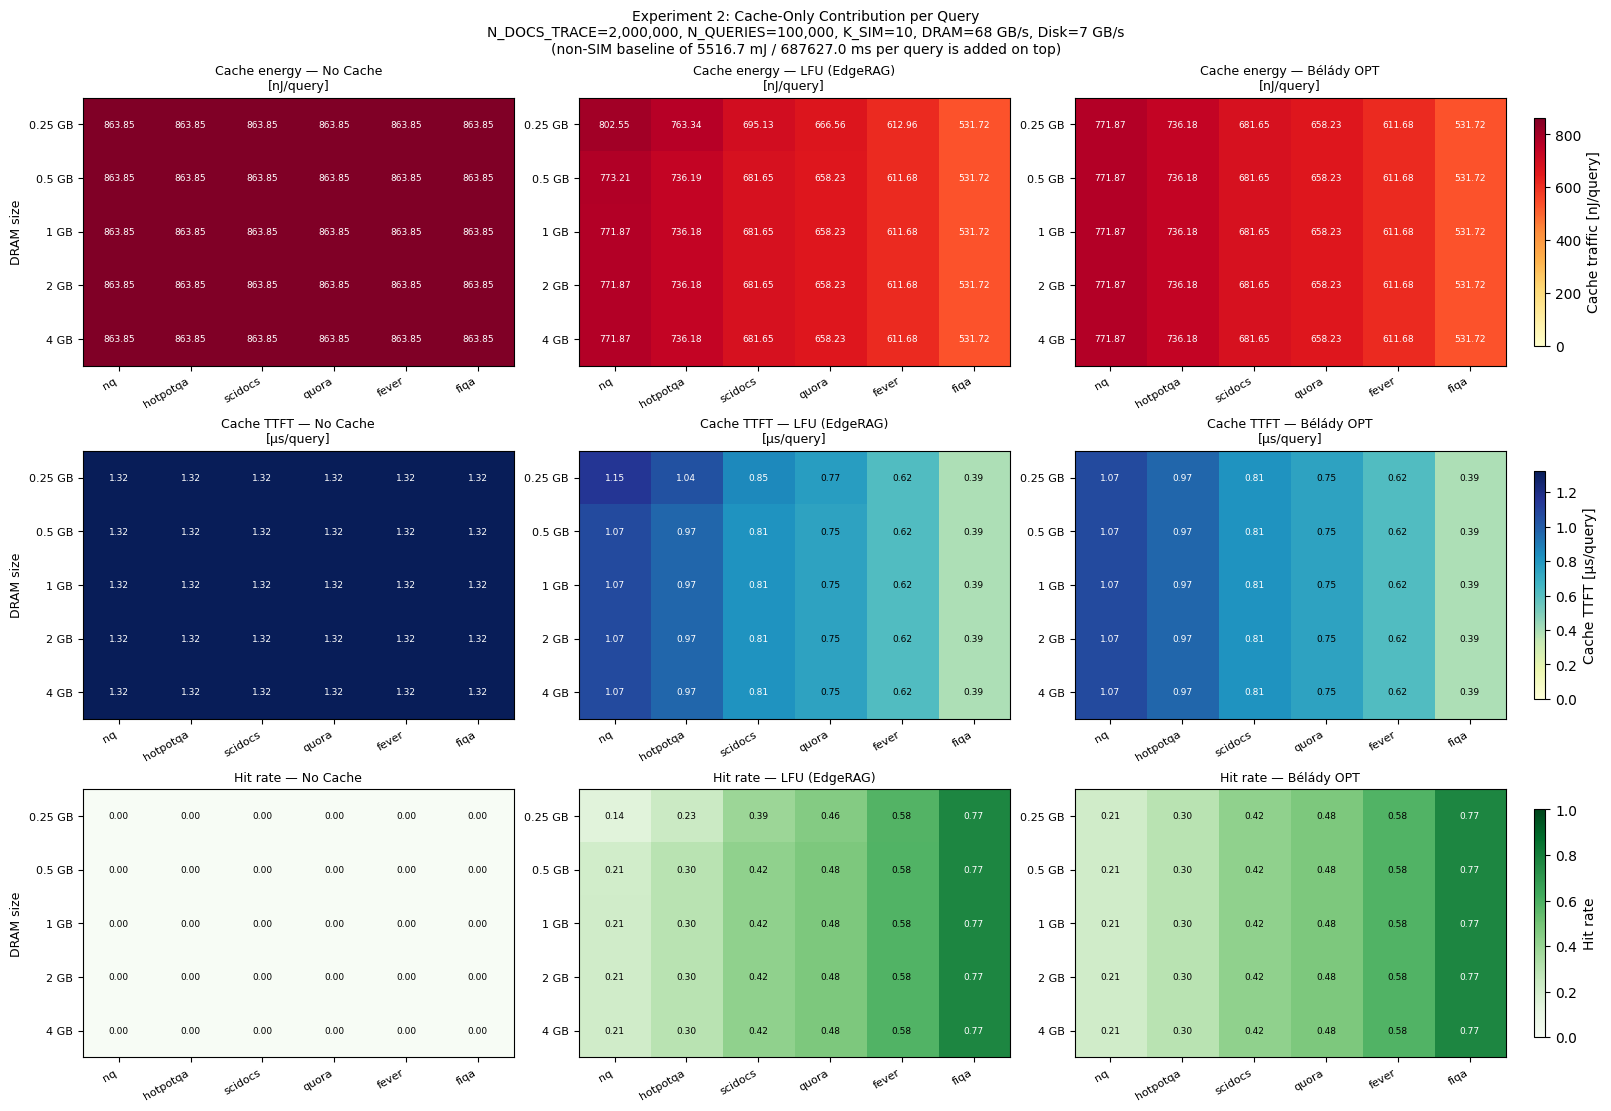

Saved exp2_heatmaps.png

=== Headline savings: LFU vs No-Cache (mean across datasets) ===
  DRAM  0.25 GB:  ΔE =  185.14 nJ,  ΔTTFT =  518.69 ns
  DRAM   0.5 GB:  ΔE =  198.40 nJ,  ΔTTFT =  555.84 ns
  DRAM     1 GB:  ΔE =  198.62 nJ,  ΔTTFT =  556.47 ns
  DRAM     2 GB:  ΔE =  198.62 nJ,  ΔTTFT =  556.47 ns
  DRAM     4 GB:  ΔE =  198.62 nJ,  ΔTTFT =  556.47 ns

=== Per-dataset LFU hit rate at smallest DRAM ===
  nq         reuse=1.25  LFU=0.142  OPT=0.213  gap=0.071
  hotpotqa   reuse=1.42  LFU=0.233  OPT=0.296  gap=0.063
  scidocs    reuse=1.73  LFU=0.391  OPT=0.422  gap=0.031
  quora      reuse=1.91  LFU=0.457  OPT=0.476  gap=0.019
  fever      reuse=2.41  LFU=0.581  OPT=0.584  gap=0.003
  fiqa       reuse=4.47  LFU=0.769  OPT=0.769  gap=0.000


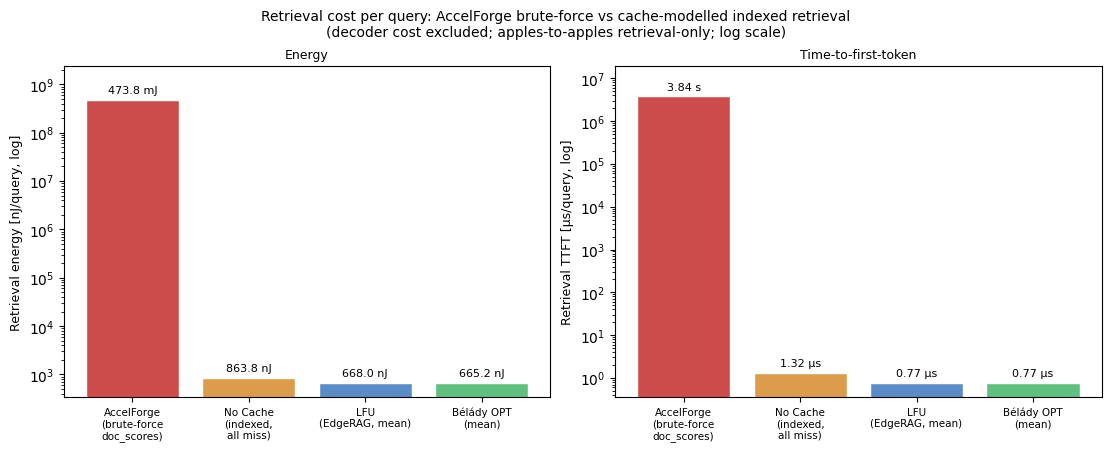

Saved exp2_baseline_compare.png

=== Stage-by-stage retrieval cost (per query) ===
  AccelForge (brute-force doc_scores)   E=  473.8 mJ   TTFT=    3.84 s
  No Cache (indexed, all miss)          E=  863.8 nJ   TTFT=   1.32 µs
  LFU (EdgeRAG, mean)                   E=  668.0 nJ   TTFT=   0.77 µs
  Bélády OPT (mean)                     E=  665.2 nJ   TTFT=   0.77 µs

=== Multipliers vs AccelForge brute-force (energy / TTFT divided by) ===
  AccelForge (brute-force doc_scores)   E ÷           1×   TTFT ÷           1×
  No Cache (indexed, all miss)          E ÷     548,455×   TTFT ÷   2,902,439×
  LFU (EdgeRAG, mean)                   E ÷     709,290×   TTFT ÷   4,959,707×
  Bélády OPT (mean)                     E ÷     712,214×   TTFT ÷   5,009,415×


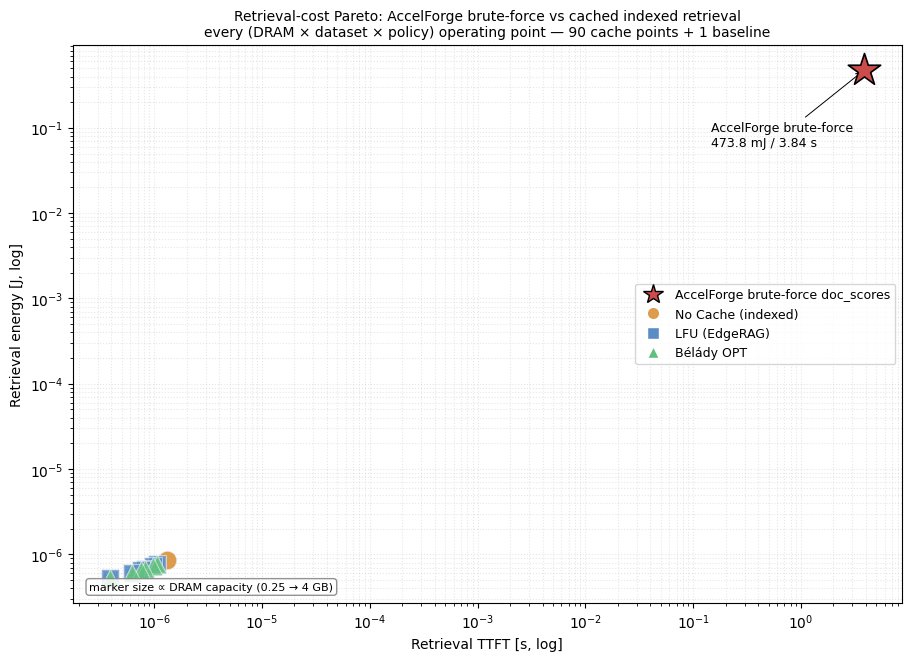

Saved exp2_pareto.png


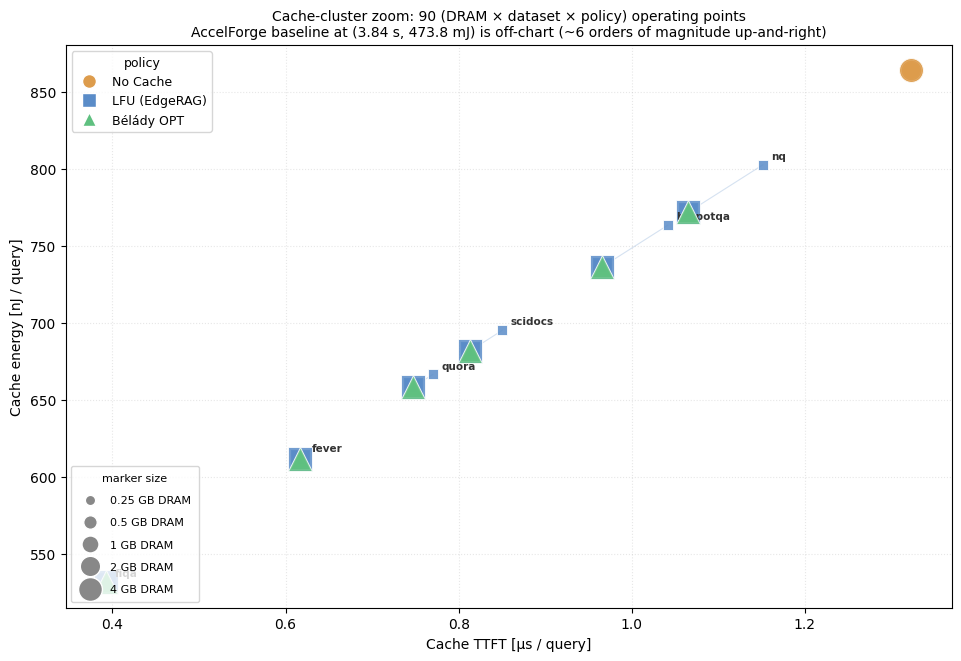

Saved exp2_pareto_zoom.png


In [8]:
POLICY_LABELS = {'no_cache': 'No Cache', 'lfu': 'LFU (EdgeRAG)', 'opt': 'Bélády OPT'}
DRAM_LABELS   = [f'{g} GB' for g in DRAM_GB_VALUES]

def draw_heatmap(ax, data, title, cmap, fmt, vmin=None, vmax=None,
                 text_color_threshold=0.6):
    vmin_eff = vmin if vmin is not None else data.min()
    vmax_eff = vmax if vmax is not None else data.max()
    im = ax.imshow(data, cmap=cmap, aspect='auto', vmin=vmin_eff, vmax=vmax_eff)
    ax.set_xticks(range(ndata))
    ax.set_xticklabels(DATASET_NAMES, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(ndram))
    ax.set_yticklabels(DRAM_LABELS, fontsize=8)
    ax.set_title(title, fontsize=9)
    span = max(vmax_eff - vmin_eff, 1e-9)
    threshold = vmin_eff + text_color_threshold * span
    for i in range(ndram):
        for j in range(ndata):
            ax.text(j, i, fmt.format(data[i, j]),
                    ha='center', va='center', fontsize=6.5,
                    color='white' if data[i, j] > threshold else 'black')
    return im

# ── Cache-only traffic (per query, in nJ / µs) ─────────────────────────────
# Strips the decoder-dominated non-SIM baseline so policy & DRAM differences
# are visible.  The original SIM doc_scores term (~470 mJ/query) is replaced
# by the cache traffic shown here.
ce_nJ  = {p: cache_energy[p] / 1e3  for p in POLICIES}   # pJ → nJ
ct_us  = {p: cache_ttft[p]   / 1e3  for p in POLICIES}   # ns → µs

ce_max = max(ce_nJ[p].max() for p in POLICIES)
ct_max = max(ct_us[p].max() for p in POLICIES)
hr_max = 1.0

fig, axes = plt.subplots(3, 3, figsize=(16, 11), constrained_layout=True)
fig.suptitle(
    f'Experiment 2: Cache-Only Contribution per Query\n'
    f'N_DOCS_TRACE={N_DOCS_TRACE:,}, N_QUERIES={N_QUERIES:,}, K_SIM={K_SIM}, '
    f'DRAM={DRAM_BW_GBps:.0f} GB/s, Disk={DISK_BW_GBps:.0f} GB/s\n'
    f'(non-SIM baseline of {nonsim_energy_J*1e3:.1f} mJ / '
    f'{nonsim_latency_s*1e3:.1f} ms per query is added on top)',
    fontsize=10,
)

for col, policy in enumerate(POLICIES):
    ax_e  = axes[0, col]
    ax_t  = axes[1, col]
    ax_h  = axes[2, col]

    im_e = draw_heatmap(
        ax_e, ce_nJ[policy],
        f'Cache energy — {POLICY_LABELS[policy]}\n[nJ/query]',
        'YlOrRd', '{:.2f}', vmin=0, vmax=ce_max,
    )
    im_t = draw_heatmap(
        ax_t, ct_us[policy],
        f'Cache TTFT — {POLICY_LABELS[policy]}\n[µs/query]',
        'YlGnBu', '{:.2f}', vmin=0, vmax=ct_max,
    )
    im_h = draw_heatmap(
        ax_h, hitrate[policy],
        f'Hit rate — {POLICY_LABELS[policy]}',
        'Greens', '{:.2f}', vmin=0, vmax=hr_max,
    )

    if col == 0:
        ax_e.set_ylabel('DRAM size', fontsize=9)
        ax_t.set_ylabel('DRAM size', fontsize=9)
        ax_h.set_ylabel('DRAM size', fontsize=9)

fig.colorbar(im_e, ax=axes[0, :].tolist(), shrink=0.85, pad=0.02,
             label='Cache traffic [nJ/query]')
fig.colorbar(im_t, ax=axes[1, :].tolist(), shrink=0.85, pad=0.02,
             label='Cache TTFT [µs/query]')
fig.colorbar(im_h, ax=axes[2, :].tolist(), shrink=0.85, pad=0.02,
             label='Hit rate')
plt.savefig('/home/workspace/workspace/exp2_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved exp2_heatmaps.png')

# ── Headline numbers (also printed for the report) ──────────────────────────
def fmt_J(j):
    return f'{j*1e3:>7.2f} mJ' if j >= 1e-3 else f'{j*1e6:>7.2f} µJ' if j >= 1e-6 else f'{j*1e9:>7.2f} nJ'
def fmt_s(s):
    return f'{s*1e3:>7.2f} ms' if s >= 1e-3 else f'{s*1e6:>7.2f} µs' if s >= 1e-6 else f'{s*1e9:>7.2f} ns'

savings_E_pJ  = energy['no_cache'] - energy['lfu']
savings_T_ns  = ttft_latency['no_cache'] - ttft_latency['lfu']
print()
print('=== Headline savings: LFU vs No-Cache (mean across datasets) ===')
for i, gb in enumerate(DRAM_GB_VALUES):
    e_save_J = savings_E_pJ[i].mean() * 1e-12
    t_save_s = savings_T_ns[i].mean() * 1e-9
    print(f'  DRAM {gb:>5g} GB:  ΔE = {fmt_J(e_save_J)},  ΔTTFT = {fmt_s(t_save_s)}')

print()
print('=== Per-dataset LFU hit rate at smallest DRAM ===')
for j, (name, reuse) in enumerate(BEIR_DATASETS):
    print(f'  {name:<10} reuse={reuse:.2f}  '
          f'LFU={hitrate["lfu"][0, j]:.3f}  OPT={hitrate["opt"][0, j]:.3f}  '
          f'gap={hitrate["opt"][0, j] - hitrate["lfu"][0, j]:.3f}')

# ── Stage-by-stage retrieval comparison (Option A: include AccelForge baseline) ──
# Compares the four retrieval strategies on a log scale.  Decoder cost is excluded
# so this is an apples-to-apples retrieval-only comparison; the corresponding
# full-pipeline numbers are obtained by adding the non-SIM baseline
# (≈ 5.52 J / 687.6 ms) to every bar.
af_e_nJ = sim_energy_J  * 1e9   # AccelForge brute-force doc_scores compute
af_t_us = sim_latency_s * 1e6

def _mean_e(p):
    return cache_energy[p].mean() / 1e3   # pJ → nJ
def _mean_t(p):
    return cache_ttft[p].mean()  / 1e3    # ns → µs

stage_names = [
    'AccelForge\n(brute-force\ndoc_scores)',
    'No Cache\n(indexed,\nall miss)',
    'LFU\n(EdgeRAG, mean)',
    'Bélády OPT\n(mean)',
]
stage_e_nJ  = [af_e_nJ, _mean_e('no_cache'), _mean_e('lfu'), _mean_e('opt')]
stage_t_us  = [af_t_us, _mean_t('no_cache'), _mean_t('lfu'), _mean_t('opt')]
stage_color = ['#cc4c4c', '#dd9c4c', '#5a8cc8', '#5fc080']

def _label_e(v):
    if v >= 1e6:  return f'{v/1e6:.1f} mJ'
    if v >= 1e3:  return f'{v/1e3:.1f} µJ'
    return f'{v:.1f} nJ'

def _label_t(v):
    if v >= 1e6:  return f'{v/1e6:.2f} s'
    if v >= 1e3:  return f'{v/1e3:.1f} ms'
    return f'{v:.2f} µs'

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
fig.suptitle(
    'Retrieval cost per query: AccelForge brute-force vs cache-modelled indexed retrieval\n'
    '(decoder cost excluded; apples-to-apples retrieval-only; log scale)',
    fontsize=10,
)

for ax, vals, ylabel, fmtter, title in [
    (axes[0], stage_e_nJ, 'Retrieval energy [nJ/query, log]', _label_e, 'Energy'),
    (axes[1], stage_t_us, 'Retrieval TTFT [µs/query, log]',   _label_t, 'Time-to-first-token'),
]:
    ax.bar(stage_names, vals, color=stage_color, edgecolor='white')
    ax.set_yscale('log')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=9)
    for i, v in enumerate(vals):
        ax.text(i, v * 1.25, fmtter(v), ha='center', va='bottom', fontsize=8)
    ax.tick_params(axis='x', labelsize=7.5)
    ax.set_ylim(top=max(vals) * 5)

plt.savefig('/home/workspace/workspace/exp2_baseline_compare.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved exp2_baseline_compare.png')

# ── Numerical stage table (with AccelForge multipliers) ──
flat_names = [s.replace('\n', ' ') for s in stage_names]
nw = max(len(n) for n in flat_names)
print()
print('=== Stage-by-stage retrieval cost (per query) ===')
for n, e, t in zip(flat_names, stage_e_nJ, stage_t_us):
    print(f'  {n:<{nw}}   E={_label_e(e):>10}   TTFT={_label_t(t):>10}')

print()
print('=== Multipliers vs AccelForge brute-force (energy / TTFT divided by) ===')
ref_e, ref_t = stage_e_nJ[0], stage_t_us[0]
for n, e, t in zip(flat_names, stage_e_nJ, stage_t_us):
    print(f'  {n:<{nw}}   E ÷ {ref_e/e:>11,.0f}×   TTFT ÷ {ref_t/t:>11,.0f}×')

# ── Retrieval-cost Pareto: every (DRAM, dataset, policy) operating point + AF baseline ──
# Retrieval-only (decoder excluded) so the AccelForge brute-force baseline and the
# cache operating points are visually separated; on a full-pipeline view they would
# overlap at log(5.5 J) / log(688 s) and the Pareto would be uninformative.
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(9, 6.5), constrained_layout=True)

policy_colors  = {'no_cache': '#dd9c4c', 'lfu': '#5a8cc8', 'opt': '#5fc080'}
policy_markers = {'no_cache': 'o',       'lfu': 's',       'opt': '^'}
# marker size grows with DRAM (0.25 → 4 GB)
size_scale     = {0.25: 35, 0.5: 60, 1: 90, 2: 130, 4: 180}

for p in POLICIES:
    for i, gb in enumerate(DRAM_GB_VALUES):
        ce_J = cache_energy[p][i, :] * 1e-12   # pJ → J
        ct_s = cache_ttft[p][i, :]   * 1e-9    # ns → s
        ax.scatter(ct_s, ce_J,
                   marker=policy_markers[p], s=size_scale[gb],
                   c=policy_colors[p], edgecolors='white',
                   alpha=0.65, linewidth=0.6)

# AccelForge brute-force baseline (single star at the upper-right)
ax.scatter(sim_latency_s, sim_energy_J, marker='*', s=600,
           c='#cc4c4c', edgecolors='black', linewidth=1.2, zorder=10)
ax.annotate(
    f'AccelForge brute-force\n{sim_energy_J*1e3:.1f} mJ / {sim_latency_s:.2f} s',
    xy=(sim_latency_s, sim_energy_J),
    xytext=(-110, -55), textcoords='offset points',
    fontsize=9, ha='left',
    arrowprops=dict(arrowstyle='->', color='black', lw=0.7),
)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Retrieval TTFT [s, log]', fontsize=10)
ax.set_ylabel('Retrieval energy [J, log]', fontsize=10)
ax.set_title(
    'Retrieval-cost Pareto: AccelForge brute-force vs cached indexed retrieval\n'
    f'every (DRAM × dataset × policy) operating point — '
    f'{len(POLICIES)*len(DRAM_GB_VALUES)*len(BEIR_DATASETS)} cache points + 1 baseline',
    fontsize=10,
)
ax.grid(True, which='both', alpha=0.3, linestyle=':')

legend_handles = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='#cc4c4c',
           markeredgecolor='black', markersize=15,
           label='AccelForge brute-force doc_scores'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#dd9c4c',
           markeredgecolor='white', markersize=9, label='No Cache (indexed)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#5a8cc8',
           markeredgecolor='white', markersize=9, label='LFU (EdgeRAG)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#5fc080',
           markeredgecolor='white', markersize=9, label='Bélády OPT'),
]
ax.legend(handles=legend_handles, loc='center right', fontsize=9, frameon=True)
ax.text(0.02, 0.02, 'marker size ∝ DRAM capacity (0.25 → 4 GB)',
        transform=ax.transAxes, fontsize=8, va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='gray', alpha=0.85))

plt.savefig('/home/workspace/workspace/exp2_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved exp2_pareto.png')

# ── Zoomed-in view of the cache cluster (AccelForge baseline off-chart) ──────
# Single panel, linear axes in nJ / µs so the LFU↔OPT spread is readable.
# Encoding matches the original Pareto (shape + color = policy, size = DRAM);
# a thin line connects each (policy, dataset) DRAM sweep so the saturation
# pattern is visible.  AccelForge baseline omitted — it sits ~6 orders of
# magnitude up-and-right and would collapse the cluster to a point if shown.
size_scale_zoom = {0.25: 55, 0.5: 95, 1: 150, 2: 215, 4: 295}

fig, ax = plt.subplots(1, 1, figsize=(9.5, 6.5), constrained_layout=True)

for p in POLICIES:
    for j, (name, _reuse) in enumerate(BEIR_DATASETS):
        ce_nJ = cache_energy[p][:, j] / 1e3   # pJ → nJ
        ct_us = cache_ttft[p][:, j]   / 1e3   # ns → µs
        ax.plot(ct_us, ce_nJ, '-', color=policy_colors[p],
                alpha=0.25, lw=0.8, zorder=1)
        for i, gb in enumerate(DRAM_GB_VALUES):
            ax.scatter(ct_us[i], ce_nJ[i],
                       marker=policy_markers[p], s=size_scale_zoom[gb],
                       facecolor=policy_colors[p], edgecolor='white',
                       linewidth=0.7, alpha=0.85, zorder=3)
        if p == 'lfu':
            ax.annotate(name, xy=(ct_us[0], ce_nJ[0]),
                        xytext=(6, 4), textcoords='offset points',
                        fontsize=7.5, color='#333', fontweight='bold')

ax.set_xlabel('Cache TTFT [µs / query]', fontsize=10)
ax.set_ylabel('Cache energy [nJ / query]', fontsize=10)
ax.set_title(
    'Cache-cluster zoom: 90 (DRAM × dataset × policy) operating points\n'
    'AccelForge baseline at (3.84 s, 473.8 mJ) is off-chart '
    '(~6 orders of magnitude up-and-right)',
    fontsize=10,
)
ax.grid(True, alpha=0.3, linestyle=':')

policy_handles = [
    Line2D([0], [0], marker=policy_markers[p], color='w',
           markerfacecolor=policy_colors[p], markeredgecolor='white',
           markersize=10, label=POLICY_LABELS[p])
    for p in POLICIES
]
size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#888',
           markeredgecolor='white',
           markersize=np.sqrt(size_scale_zoom[gb]),
           label=f'{gb} GB DRAM')
    for gb in DRAM_GB_VALUES
]
leg1 = ax.legend(handles=policy_handles, loc='upper left', fontsize=9,
                 title='policy', title_fontsize=9, frameon=True)
ax.add_artist(leg1)
ax.legend(handles=size_handles, loc='lower left', fontsize=8,
          title='marker size', title_fontsize=8,
          labelspacing=1.1, borderpad=0.7, frameon=True)

plt.savefig('/home/workspace/workspace/exp2_pareto_zoom.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved exp2_pareto_zoom.png')

## Cell 8 — LFU-vs-OPT headroom gap plot

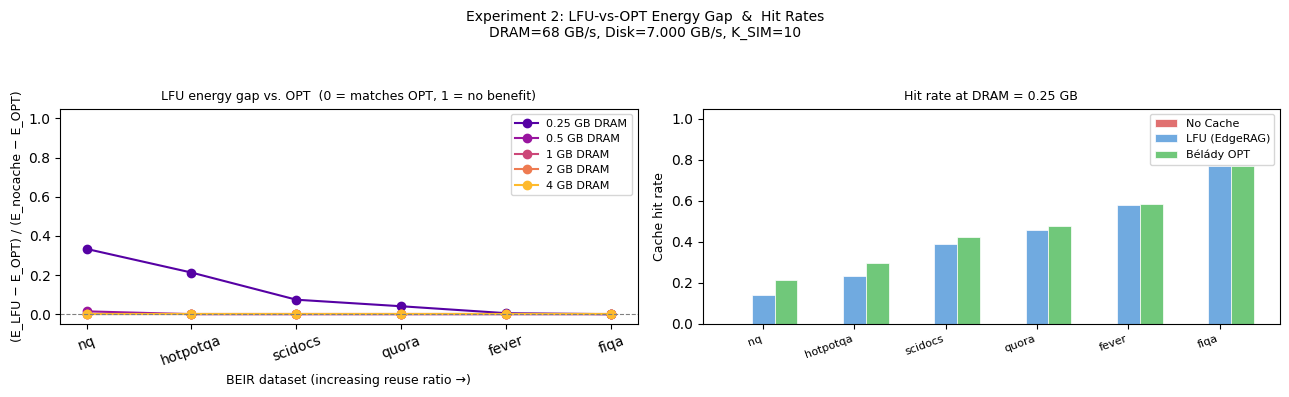

Saved exp2_gap_hitrate.png


In [9]:
# gap[i,j] = (E_LFU - E_OPT) / (E_nocache - E_OPT)
# 0 = LFU achieves OPT; 1 = LFU is no better than no cache.
# Clamped to [0, 1] to handle numerical noise.

denominator = energy['no_cache'] - energy['opt']
safe_denom  = np.where(np.abs(denominator) < 1e-6, np.nan, denominator)
gap         = np.clip((energy['lfu'] - energy['opt']) / safe_denom, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    f'Experiment 2: LFU-vs-OPT Energy Gap  &  Hit Rates\n'
    f'DRAM={DRAM_BW_GBps:.0f} GB/s, Disk={DISK_BW_GBps:.3f} GB/s, K_SIM={K_SIM}',
    fontsize=10,
)

# --- Left: gap line plot ---
ax = axes[0]
colors = plt.cm.plasma(np.linspace(0.15, 0.85, ndram))
for i, (gb, c) in enumerate(zip(DRAM_GB_VALUES, colors)):
    row = gap[i, :]
    ax.plot(DATASET_NAMES, row, marker='o', color=c, label=f'{gb} GB DRAM')
ax.set_xlabel('BEIR dataset (increasing reuse ratio →)', fontsize=9)
ax.set_ylabel('(E_LFU − E_OPT) / (E_nocache − E_OPT)', fontsize=9)
ax.set_title('LFU energy gap vs. OPT  (0 = matches OPT, 1 = no benefit)', fontsize=9)
ax.set_ylim(-0.05, 1.05)
ax.axhline(0, ls='--', lw=0.8, color='gray')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=20)

# --- Right: hit-rate bar chart at representative DRAM size ---
REP_DRAM_IDX = 0  # 1 GB
rep_gb = DRAM_GB_VALUES[REP_DRAM_IDX]

ax2 = axes[1]
x   = np.arange(ndata)
w   = 0.25
policy_colors = {'no_cache': '#e07070', 'lfu': '#70aae0', 'opt': '#70c87a'}
for k, policy in enumerate(POLICIES):
    ax2.bar(x + k * w, hitrate[policy][REP_DRAM_IDX, :],
            width=w, label=POLICY_LABELS[policy],
            color=policy_colors[policy], edgecolor='white', linewidth=0.5)
ax2.set_xticks(x + w)
ax2.set_xticklabels(DATASET_NAMES, rotation=20, ha='right', fontsize=8)
ax2.set_ylabel('Cache hit rate', fontsize=9)
ax2.set_title(f'Hit rate at DRAM = {rep_gb} GB', fontsize=9)
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('/home/workspace/workspace/exp2_gap_hitrate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved exp2_gap_hitrate.png')

## Cell 9 — Raw numbers table

In [10]:
import pandas as pd

rows = []
for i, gb in enumerate(DRAM_GB_VALUES):
    capacity = embedding_capacity(gb, N_DOCS_TRACE)
    for j, (name, reuse) in enumerate(BEIR_DATASETS):
        for p in POLICIES:
            res = sim_results[gb][name][p]
            rows.append({
                'DRAM_GB':             gb,
                'capacity_embeddings': capacity,
                'dataset':             name,
                'reuse':               reuse,
                'policy':              p,
                'hits':                res.hits,
                'misses':              res.misses,
                'hit_rate':            f'{res.hit_rate:.3f}',
                'energy_nJ_per_query': f'{energy[p][i,j]/1e3:.1f}',
                'ttft_us_per_query':   f'{ttft_latency[p][i,j]/1e3:.2f}',
                'edp_pJ_ns':           f'{edp[p][i,j]:.2e}',
            })

df = pd.DataFrame(rows)
pd.set_option('display.max_rows', 120)
display(df)
df.to_csv('/home/workspace/workspace/exp2_raw_results.csv', index=False)
print(f'Saved exp2_raw_results.csv  ({len(df)} rows)')

,DRAM_GB,capacity_embeddings,dataset,reuse,policy,hits,misses,hit_rate,energy_nJ_per_query,ttft_us_per_query,edp_pJ_ns
0,0.25,349525,nq,1.25,no_cache,0,1000000,0.000,5516689810.2,687626975.91,3.79e+24
1,0.25,349525,nq,1.25,lfu,141918,858082,0.142,5516689748.9,687626975.74,3.79e+24
2,0.25,349525,nq,1.25,opt,212939,787061,0.213,5516689718.2,687626975.65,3.79e+24
3,0.25,349525,hotpotqa,1.42,no_cache,0,1000000,0.000,5516689810.2,687626975.91,3.79e+24
4,0.25,349525,hotpotqa,1.42,lfu,232706,767294,0.233,5516689709.7,687626975.63,3.79e+24
5,0.25,349525,hotpotqa,1.42,opt,295586,704414,0.296,5516689682.5,687626975.55,3.79e+24
6,0.25,349525,scidocs,1.73,no_cache,0,1000000,0.000,5516689810.2,687626975.91,3.79e+24
7,0.25,349525,scidocs,1.73,lfu,390621,609379,0.391,5516689641.5,687626975.44,3.79e+24
8,0.25,349525,scidocs,1.73,opt,421815,578185,0.422,5516689628.0,687626975.40,3.79e+24
9,0.25,349525,quora,1.91,no_cache,0,1000000,0.000,5516689810.2,687626975.91,3.79e+24


Saved exp2_raw_results.csv  (90 rows)
